# Project 1: AI-Powered Emotion Detection from Text
This notebook demonstrates an end-to-end NLP pipeline to classify the emotional tone of text. We will use the `dair-ai/emotion` dataset from Hugging Face, preprocess it, and train a Logistic Regression model using TF-IDF features.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import nltk

import warnings
warnings.filterwarnings('ignore')

## 1. Dataset Collection
We will load the `dair-ai/emotion` dataset. It consists of English Twitter messages with six basic emotions: anger, fear, joy, love, sadness, and surprise.

In [2]:
# Load dataset from Hugging Face
dataset = load_dataset("dair-ai/emotion", "split")
train_df = dataset['train'].to_pandas()
test_df = dataset['test'].to_pandas()

label_mapping = {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}
train_df['label_name'] = train_df['label'].map(label_mapping)
test_df['label_name'] = test_df['label'].map(label_mapping)

train_df.head()

,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


## 2. Exploratory Data Analysis (EDA)

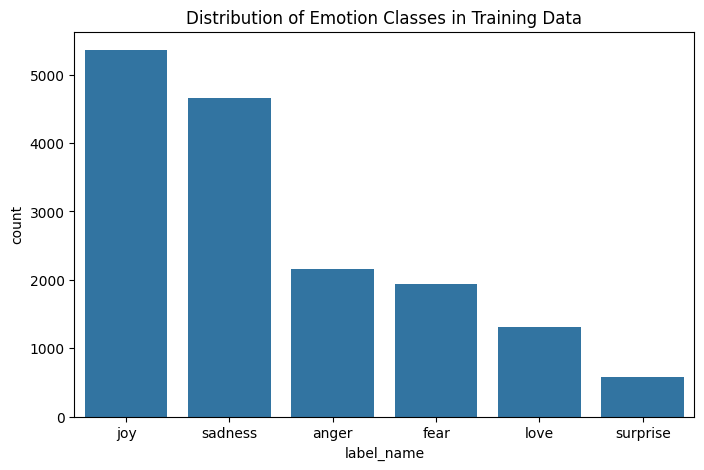

In [3]:
plt.figure(figsize=(8, 5))
sns.countplot(data=train_df, x='label_name', order=train_df['label_name'].value_counts().index)
plt.title('Distribution of Emotion Classes in Training Data')
plt.show()

## 3. Text Preprocessing
We will clean the text (lowercasing, special char removal) and apply tokenization, stopword removal, and lemmatization using NLTK.

In [4]:
from data_preprocessing import preprocess_text

# Apply preprocessing to train and test sets
train_df['clean_text'] = train_df['text'].apply(preprocess_text)
test_df['clean_text'] = test_df['text'].apply(preprocess_text)

train_df[['text', 'clean_text']].head()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\suman\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\suman\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\suman\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\suman\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\suman\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,text,clean_text
0,i didnt feel humiliated,didnt feel humiliated
1,i can go from feeling so hopeless to so damned...,go feeling hopeless damned hopeful around some...
2,im grabbing a minute to post i feel greedy wrong,grabbing minute post feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...,ever feeling nostalgic fireplace know still pr...
4,i am feeling grouchy,feeling grouchy


## 4. Feature Extraction (TF-IDF)
We convert the cleaned text into numerical vectors using `TfidfVectorizer`.

In [5]:
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train = vectorizer.fit_transform(train_df['clean_text'])
y_train = train_df['label']

X_test = vectorizer.transform(test_df['clean_text'])
y_test = test_df['label']

print(f"Train features shape: {X_train.shape}")
print(f"Test features shape: {X_test.shape}")

Train features shape: (16000, 5000)
Test features shape: (2000, 5000)


## 5. Model Building
We will train a Logistic Regression classifier.

In [6]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


## 6. Model Evaluation
Evaluate the model using Accuracy, F1-score, and a Confusion Matrix.

In [7]:
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=[label_mapping[i] for i in range(6)]))

Accuracy: 0.8910
F1 Score: 0.8936

Classification Report:
               precision    recall  f1-score   support

     sadness       0.95      0.90      0.93       581
         joy       0.94      0.88      0.91       695
        love       0.70      0.93      0.80       159
       anger       0.87      0.92      0.89       275
        fear       0.90      0.83      0.86       224
    surprise       0.63      0.89      0.74        66

    accuracy                           0.89      2000
   macro avg       0.83      0.89      0.86      2000
weighted avg       0.90      0.89      0.89      2000



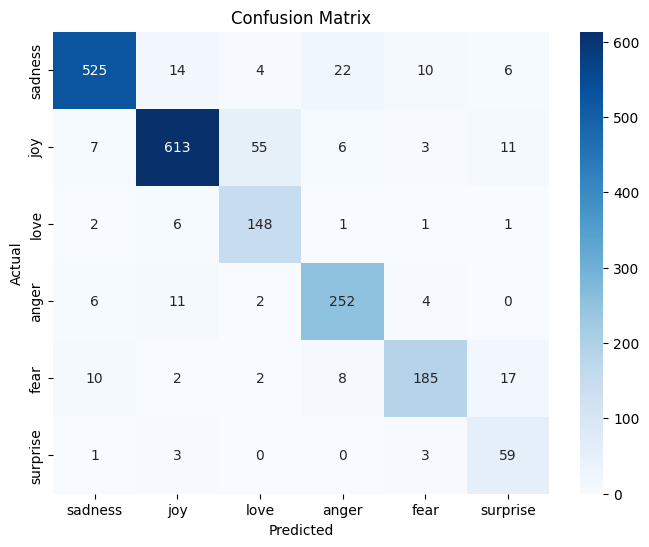

In [8]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[label_mapping[i] for i in range(6)], yticklabels=[label_mapping[i] for i in range(6)])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## 7. Make Predictions on New Text
Let's test our model with some custom inputs.

In [9]:
def predict_emotion(text):
    cleaned = preprocess_text(text)
    features = vectorizer.transform([cleaned])
    pred = model.predict(features)[0]
    return label_mapping[pred]

samples = [
    "I am so excited to learn Natural Language Processing!",
    "This was the worst movie I have ever seen.",
    "I'm terrified of what might happen next.",
    "I am completely amazed and shocked by this news!"
]

for sample in samples:
    print(f"Text: '{sample}'\nPredicted Emotion: {predict_emotion(sample).upper()}\n")

Text: 'I am so excited to learn Natural Language Processing!'
Predicted Emotion: JOY

Text: 'This was the worst movie I have ever seen.'
Predicted Emotion: JOY

Text: 'I'm terrified of what might happen next.'
Predicted Emotion: FEAR

Text: 'I am completely amazed and shocked by this news!'
Predicted Emotion: SURPRISE

